#1. **Importing libraries**

In [5]:
# Import necessary libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Import model selection and evaluation tools
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.metrics import make_scorer, accuracy_score, precision_score, recall_score, f1_score

# Import preprocessing tools
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Import classification models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.dummy import DummyClassifier

# Import advanced classifiers
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

# Import imbalance handling techniques
from imblearn.over_sampling import SMOTE, RandomOverSampler, BorderlineSMOTE
from imblearn.under_sampling import RandomUnderSampler, TomekLinks, ClusterCentroids, NearMiss

#**2. Data Loading**

In [6]:
water_quality_df = pd.read_csv('/content/Water Quality Prediction 1 (1).csv')
water_quality_df.head()

,Index,pH,Iron,Nitrate,Chloride,Lead,Zinc,Color,Turbidity,Fluoride,...,Chlorine,Manganese,Total Dissolved Solids,Source,Water Temperature,Air Temperature,Month,Day,Time of Day,Target
0,0,8.332988,0.000083,8.605777,122.799772,3.710000e-52,3.434827,Colorless,0.022683,0.607283,...,3.708178,2.270000e-15,332.118789,NaN,NaN,43.493324,January,29.0,4.0,0
1,1,6.917863,0.000081,3.734167,227.029851,7.850000e-94,1.245317,Faint Yellow,0.019007,0.622874,...,3.292038,8.020000e-07,284.641984,Lake,15.348981,71.220586,November,26.0,16.0,0
2,2,5.443762,0.020106,3.816994,230.995630,5.290000e-76,0.528280,Light Yellow,0.319956,0.423423,...,3.560224,7.007989e-02,570.054094,River,11.643467,44.891330,January,31.0,8.0,0
3,3,7.955339,0.143988,8.224944,178.129940,4.000000e-176,4.027879,Near Colorless,0.166319,0.208454,...,3.516907,2.468295e-02,100.043838,Ground,10.092392,60.843233,April,1.0,21.0,0
4,4,8.091909,0.002167,9.925788,186.540872,4.170000e-132,3.807511,Light Yellow,0.004867,0.222912,...,3.177849,3.296139e-03,168.075545,Spring,15.249416,69.336671,June,29.0,7.0,0


#**3. Data Understanding**

In [7]:
water_quality_df.shape

(1048575, 24)

In [8]:
water_quality_df.describe()

,Index,pH,Iron,Nitrate,Chloride,Lead,Zinc,Turbidity,Fluoride,Copper,...,Sulfate,Conductivity,Chlorine,Manganese,Total Dissolved Solids,Water Temperature,Air Temperature,Day,Time of Day,Target
count,1.048575e+06,1.028344e+06,1.041584e+06,1.029880e+06,1.017741e+06,1.043891e+06,1.020900e+06,1.039881e+06,1.015357e+06,1.013693e+06,...,1.014050e+06,1.019772e+06,1.038413e+06,1.029236e+06,1.048277e+06,1.018887e+06,1.043272e+06,1.031026e+06,1.028214e+06,1.048575e+06
mean,5.242870e+05,7.449869e+00,1.139646e-01,6.078584e+00,1.818660e+02,1.291635e-03,1.528928e+00,4.835915e-01,9.410137e-01,4.939443e-01,...,1.446009e+02,4.248376e+02,3.236978e+00,9.352826e-02,2.647872e+02,1.915360e+01,6.003251e+01,1.573196e+01,1.149062e+01,2.295821e-01
std,3.026977e+05,8.478455e-01,4.433188e-01,3.131874e+00,6.576657e+01,3.030129e-02,1.505436e+00,8.614735e-01,7.924903e-01,5.662430e-01,...,6.672156e+01,1.897561e+02,7.150808e-01,4.403703e-01,1.543697e+02,1.137963e+01,1.808397e+01,8.798726e+00,6.925925e+00,4.205643e-01
min,0.000000e+00,2.058008e+00,2.050000e-53,2.861727e-01,2.941350e+01,0.000000e+00,6.350000e-07,1.410000e-14,4.550000e-06,2.100000e-09,...,1.194073e+01,1.305482e+01,9.994110e-01,1.380000e-46,1.064299e-02,6.661938e-01,-3.387091e+01,1.000000e+00,0.000000e+00,0.000000e+00
25%,2.621435e+05,6.914812e+00,8.950000e-06,3.952811e+00,1.374347e+02,8.290000e-123,4.127921e-01,3.692472e-02,3.706065e-01,1.260900e-01,...,9.746143e+01,2.863260e+02,2.737515e+00,2.060000e-06,1.318069e+02,1.135982e+01,4.784209e+01,8.000000e+00,5.000000e+00,0.000000e+00
50%,5.242870e+05,7.452940e+00,2.054149e-03,5.564798e+00,1.747464e+02,1.520000e-62,1.074800e+00,1.997574e-01,7.654291e-01,3.389322e-01,...,1.339778e+02,3.970023e+02,3.198937e+00,5.372950e-04,2.635694e+02,1.646738e+01,6.002168e+01,1.600000e+01,1.100000e+01,0.000000e+00
75%,7.864305e+05,8.001406e+00,4.977795e-02,7.584930e+00,2.156446e+02,2.820000e-27,2.214154e+00,5.928613e-01,1.318265e+00,6.789152e-01,...,1.803459e+02,5.333383e+02,3.685177e+00,1.369394e-02,3.949597e+02,2.386571e+01,7.223478e+01,2.300000e+01,1.700000e+01,0.000000e+00
max,1.048574e+06,1.289196e+01,1.574860e+01,7.307293e+01,1.430549e+03,3.503948e+00,2.836867e+01,1.929611e+01,1.285171e+01,1.139056e+01,...,1.393433e+03,1.891516e+03,1.068842e+01,2.374086e+01,5.797995e+02,2.430051e+02,1.440785e+02,3.100000e+01,2.300000e+01,1.000000e+00


#**4. Data Cleaning**

In [9]:
print(water_quality_df.dtypes)

Index                       int64
pH                        float64
Iron                      float64
Nitrate                   float64
Chloride                  float64
Lead                      float64
Zinc                      float64
Color                      object
Turbidity                 float64
Fluoride                  float64
Copper                    float64
Odor                      float64
Sulfate                   float64
Conductivity              float64
Chlorine                  float64
Manganese                 float64
Total Dissolved Solids    float64
Source                     object
Water Temperature         float64
Air Temperature           float64
Month                      object
Day                       float64
Time of Day               float64
Target                      int64
dtype: object


**Removing Index(Not Needed)**

In [10]:
water_quality_df.drop(columns=['Index'], inplace=True)


In [11]:
# Checking for missing values in each column
missing_values = water_quality_df.isnull().sum()

# Calculate total missing values across the entire dataset
total_missing = missing_values.sum()

# Display results
print(missing_values)  # Shows missing values per column
print("\nTotal Missing Values in Dataset:", total_missing)  # Displays total missing count

pH                        20231
Iron                       6991
Nitrate                   18695
Chloride                  30834
Lead                       4684
Zinc                      27675
Color                       981
Turbidity                  8694
Fluoride                  33218
Copper                    34882
Odor                      31332
Sulfate                   34525
Conductivity              28803
Chlorine                  10162
Manganese                 19339
Total Dissolved Solids      298
Source                    15535
Water Temperature         29688
Air Temperature            5303
Month                     16921
Day                       17549
Time of Day               20361
Target                        0
dtype: int64

Total Missing Values in Dataset: 416701


Data types are correct


**Check for Unusual Entries (Typos)**

In [12]:
# Display all unique values for categorical columns
for col in water_quality_df.select_dtypes(include=['object']).columns:
    print(f"Unique values in {col}: {water_quality_df[col].unique()}")

Unique values in Color: ['Colorless' 'Faint Yellow' 'Light Yellow' 'Near Colorless' 'Yellow' nan]
Unique values in Source: [nan 'Lake' 'River' 'Ground' 'Spring' 'Stream' 'Aquifer' 'Reservoir'
 'Well']
Unique values in Month: ['January' 'November' 'April' 'June' 'March' 'September' 'May' 'July'
 'August' 'October' 'December' 'February' nan]


1- Color Column:

'Near Colorless' might be a slight variation of 'Colorless', so I merge them.

In [13]:
# Standardize 'Near Colorless' to 'Colorless' (if they are essentially the same)
water_quality_df['Color'] = water_quality_df['Color'].replace({'Near Colorless': 'Colorless'})

In [14]:
# Identify numerical columns that might contain non-numeric values
numeric_cols = water_quality_df.select_dtypes(include=['number']).columns  # Only numeric columns

# Check if any non-numeric values exist in numerical columns
for col in numeric_cols:
    # Convert column to string temporarily for analysis
    non_numeric_values = water_quality_df[col].astype(str).str.replace(r'[-+]?[0-9]*\.?[0-9]+', '', regex=True).unique()

    # Remove truly empty values (should be '')
    non_numeric_values = [val for val in non_numeric_values if val.strip()]

    # Print only if non-numeric values are found
    if non_numeric_values:
        print(f"Potential non-numeric values in '{col}': {non_numeric_values}")
        print("-" * 50)

Potential non-numeric values in 'pH': ['nan']
--------------------------------------------------
Potential non-numeric values in 'Iron': ['e', 'nan']
--------------------------------------------------
Potential non-numeric values in 'Nitrate': ['nan']
--------------------------------------------------
Potential non-numeric values in 'Chloride': ['nan']
--------------------------------------------------
Potential non-numeric values in 'Lead': ['e', 'nan']
--------------------------------------------------
Potential non-numeric values in 'Zinc': ['nan', 'e']
--------------------------------------------------
Potential non-numeric values in 'Turbidity': ['e', 'nan']
--------------------------------------------------
Potential non-numeric values in 'Fluoride': ['nan', 'e']
--------------------------------------------------
Potential non-numeric values in 'Copper': ['nan', 'e']
--------------------------------------------------
Potential non-numeric values in 'Odor': ['nan']
---------------

In [15]:
# Strip spaces and convert text to lowercase, handling only string values
water_quality_df = water_quality_df.apply(lambda col: col.map(lambda x: x.strip().lower() if isinstance(x, str) else x))

In [16]:
# Replace different missing value indicators with NaN
water_quality_df.replace(["nan", "NaN", "NAN", "n/a", "N/A", "null", "NULL", "-", "?"], np.nan, inplace=True)

In [17]:
# Display a part of numbers containing 'e'

# Select the column where 'e' appears
col = 'Iron'

# Convert column to string and filter rows that contain 'e'
scientific_notation_values = water_quality_df[water_quality_df[col].astype(str).str.contains('e', na=False)][col]

# Display results
print(f"Numbers containing 'e' in '{col}':")
print(scientific_notation_values.head(10))  # Show first 10 occurrences

Numbers containing 'e' in 'Iron':
0     8.350000e-05
1     8.050000e-05
5     6.440000e-06
7     6.110000e-09
8     8.080000e-10
11    1.160000e-14
13    3.110000e-05
14    5.550000e-05
16    5.760000e-05
21    4.110000e-10
Name: Iron, dtype: float64


**Dropping missing values**

In [18]:
# Drop the missing values
water_quality_df.dropna(inplace=True)

In [19]:
# Check the missing values
water_quality_df.isnull().sum()

,0
pH,0
Iron,0
Nitrate,0
Chloride,0
Lead,0
Zinc,0
Color,0
Turbidity,0
Fluoride,0
Copper,0


In [20]:
# Check the column
water_quality_df.columns

Index(['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Color',
       'Turbidity', 'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity',
       'Chlorine', 'Manganese', 'Total Dissolved Solids', 'Source',
       'Water Temperature', 'Air Temperature', 'Month', 'Day', 'Time of Day',
       'Target'],
      dtype='object')

In [21]:
# Handle Unrealistic Temperature Values
# Define expected ranges for logical constraints
logical_constraints = {
    "pH": (0, 14),
    "Water Temperature": (0, 140),
    "Air Temperature": (-50, 130),
    "Day": (1, 31),
    "Turbidity": (0, float("inf")),  # Should be non-negative
    "Chlorine": (0, float("inf")),
    "Manganese": (0, float("inf")),
    "Total Dissolved Solids": (0, float("inf")),
    "Iron": (0, float("inf")),
    "Nitrate": (0, float("inf")),
    "Chloride": (0, float("inf")),
    "Lead": (0, float("inf")),
    "Zinc": (0, float("inf")),
    "Fluoride": (0, float("inf")),
    "Copper": (0, float("inf")),
    "Odor": (0, float("inf")),
    "Sulfate": (0, float("inf")),
    "Conductivity": (0, float("inf"))
}

# Function to check logical constraints
def check_invalid_ranges(df, constraints):
    for col, (min_val, max_val) in constraints.items():
        if col in df.columns:
            invalid_values = df[(df[col] < min_val) | (df[col] > max_val)][col]
            if not invalid_values.empty:
                print(f"Logical constraint violated in '{col}':")
                print(invalid_values)

# Run the function to check for invalid values
check_invalid_ranges(water_quality_df, logical_constraints)

Logical constraint violated in 'Water Temperature':
54676      149.387948
115068     167.054300
116367     151.824993
139119     141.017232
159111     151.517717
247190     153.637106
259591     147.872373
347856     161.035013
355180     144.420419
365331     161.261876
392337     144.420419
438569     146.656812
496787     144.808264
506847     177.777502
523672     158.614476
541513     147.256254
558396     146.549355
567832     174.559262
594231     148.859238
669500     159.087132
670689     143.155393
693426     187.747872
700793     147.865274
703154     178.071816
758322     144.601723
781965     147.256254
850505     141.294874
859326     150.281557
906266     156.069190
965189     157.794885
990380     142.476229
997594     153.581002
1021449    210.821909
Name: Water Temperature, dtype: float64
Logical constraint violated in 'Air Temperature':
22838      131.888212
55696      130.229783
144193     130.424080
146096     140.642152
158936     132.596241
166418     130.528713


#**5.EDA**

In [22]:
# Check the Target column value counts
water_quality_df['Target'].value_counts()

,count
Target,
0,539773
1,161283


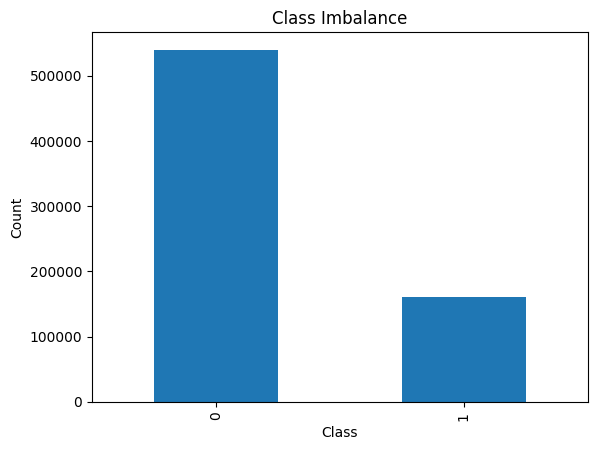

In [23]:
# Check the class imbalance
water_quality_df['Target'].value_counts().plot(kind='bar')
plt.title('Class Imbalance')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

**Numerical Feature Distributions**

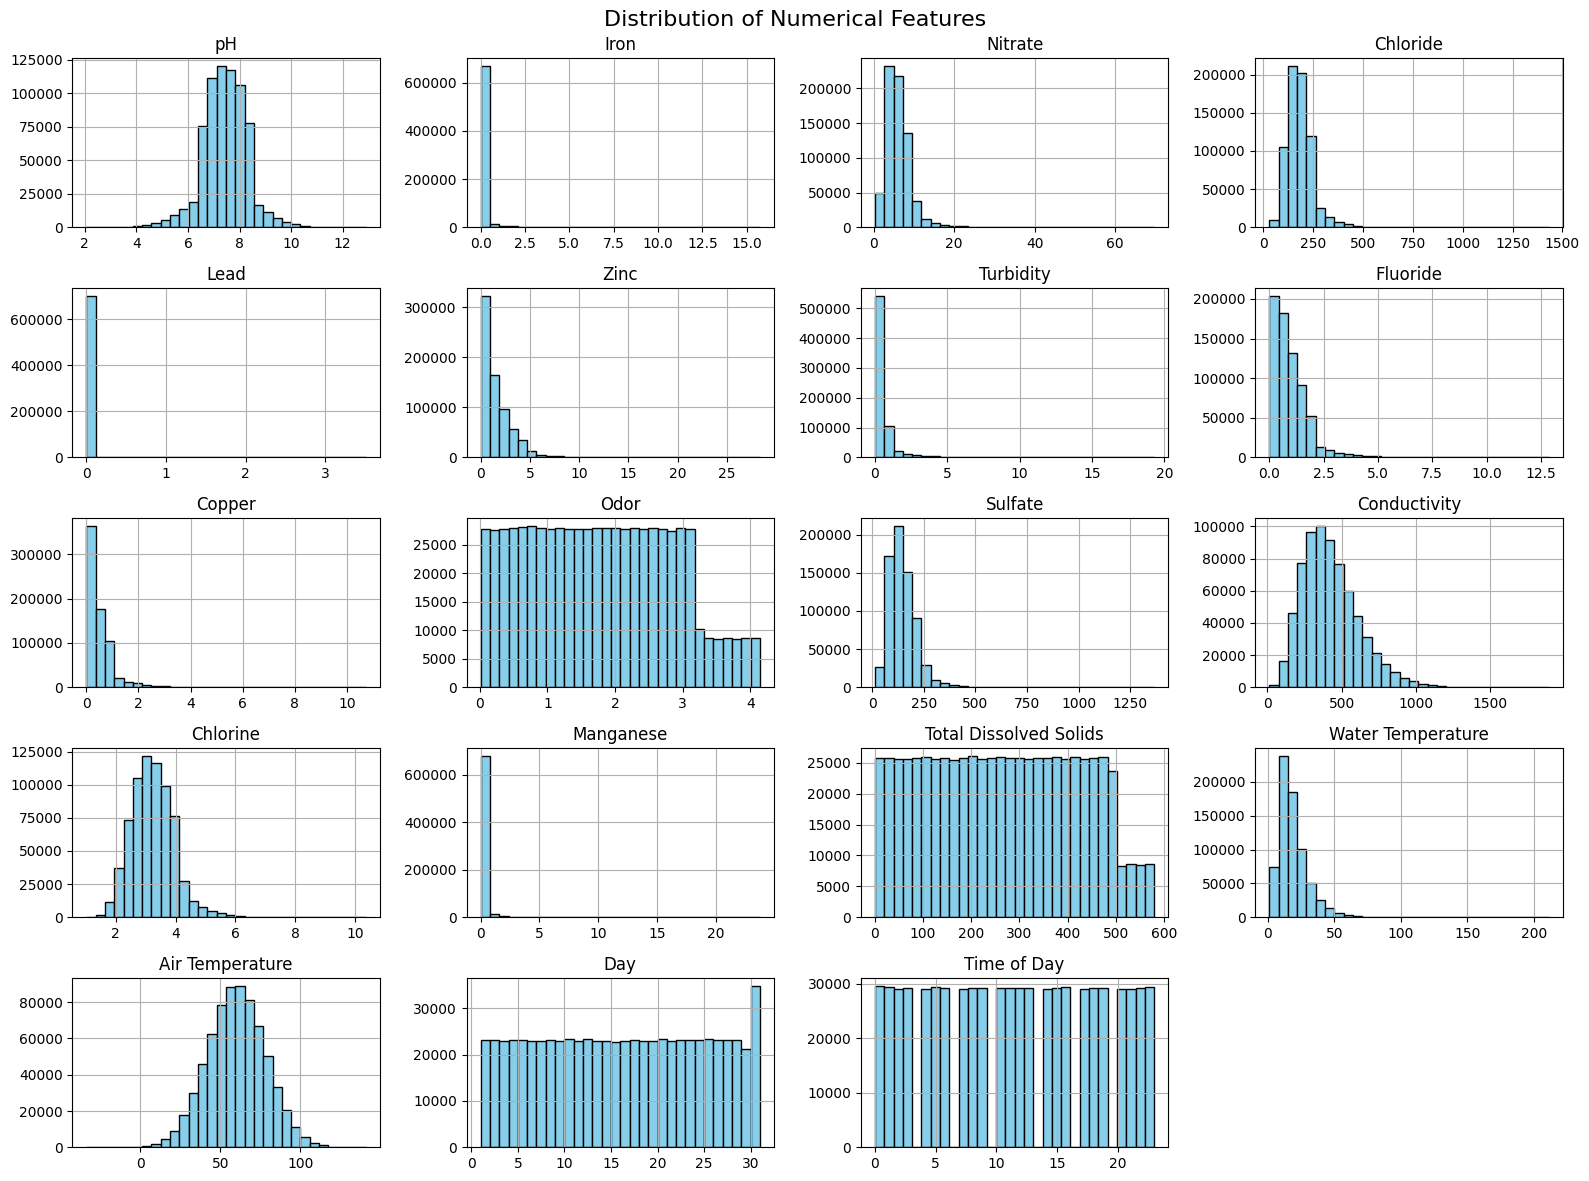

In [24]:
import matplotlib.pyplot as plt

# Select numerical columns excluding 'Target'
numerical_cols = water_quality_df.select_dtypes(include=['float64', 'int64']).drop(columns=['Target']).columns

# Plot histograms
water_quality_df[numerical_cols].hist(figsize=(16, 12), bins=30, color='skyblue', edgecolor='black')
plt.suptitle("Distribution of Numerical Features", fontsize=16)
plt.tight_layout()
plt.show()


**Categorical Value Counts (Without Encoding)**


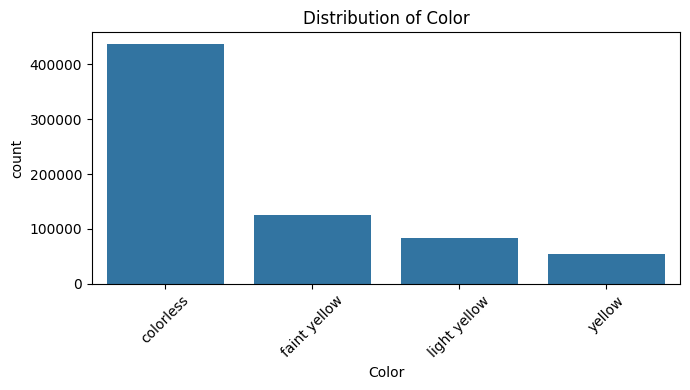

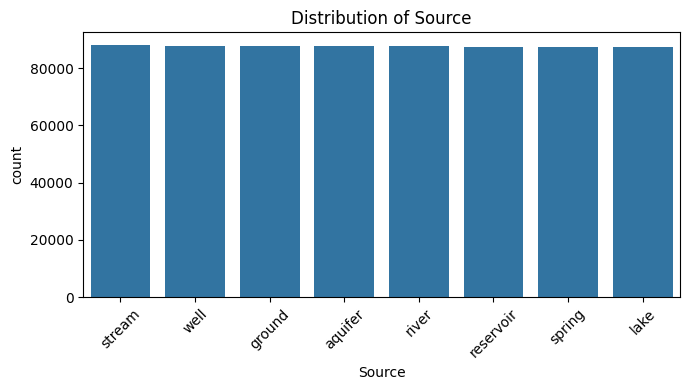

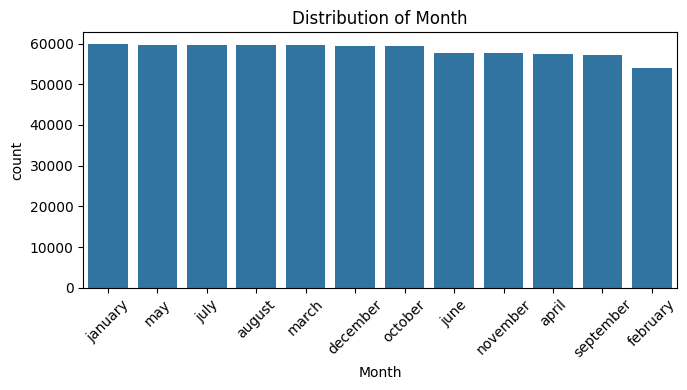

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

categorical_cols = ['Color', 'Source', 'Month']

for col in categorical_cols:
    plt.figure(figsize=(7, 4))
    sns.countplot(data=water_quality_df, x=col, order=water_quality_df[col].value_counts().index)
    plt.title(f'Distribution of {col}')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


**Correlation Heatmap (Numerical Columns)**

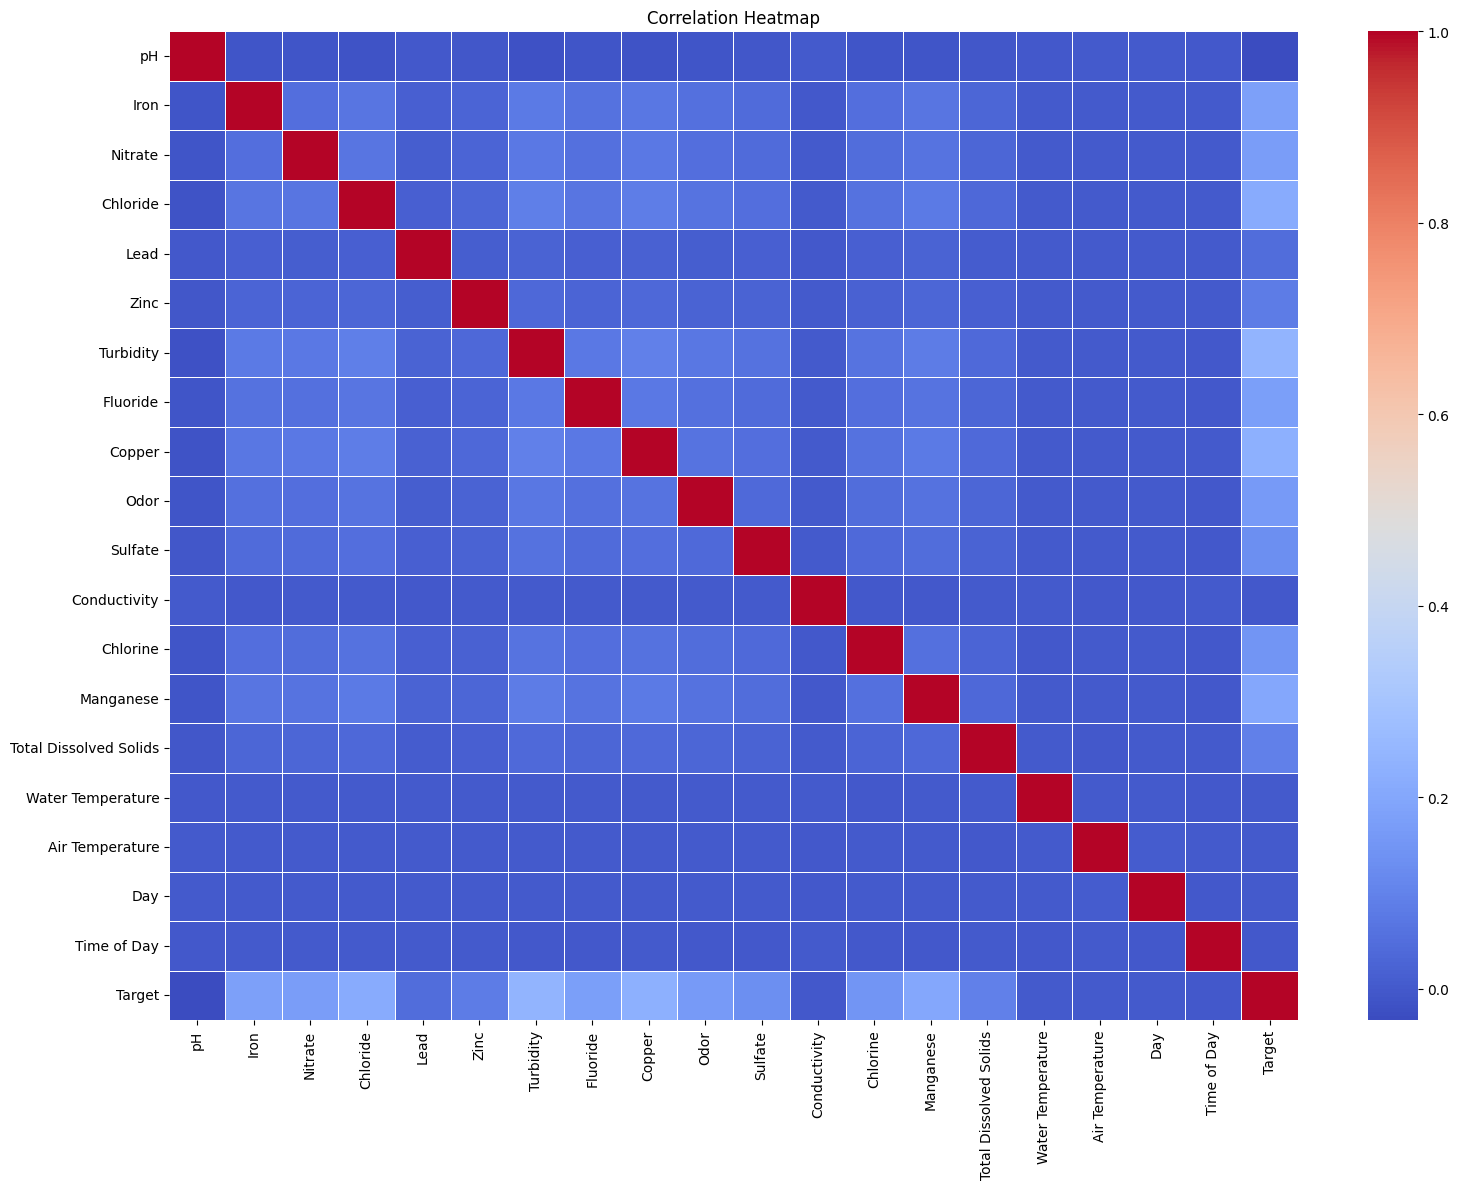

In [26]:
plt.figure(figsize=(16, 12))
corr = water_quality_df.select_dtypes(include=['float64', 'int64']).corr()
sns.heatmap(corr, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()


**VIF SCORES**

In [27]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import pandas as pd

# Step 1: Select only numerical features (drop target)
X = water_quality_df.select_dtypes(include=['float64', 'int64']).drop(columns=['Target'])

# Optional: If you've already scaled the data, you can skip scaling here

# Step 2: Add a constant (intercept) for VIF calculation
X_const = add_constant(X)

# Step 3: Compute VIF scores
vif_data = pd.DataFrame()
vif_data["Feature"] = X.columns
vif_data["VIF"] = [variance_inflation_factor(X_const.values, i + 1) for i in range(X.shape[1])]  # skip constant

# Display
print(vif_data.sort_values(by="VIF", ascending=False))


                   Feature       VIF
6                Turbidity  1.038653
8                   Copper  1.035814
3                 Chloride  1.031653
13               Manganese  1.028131
1                     Iron  1.023313
7                 Fluoride  1.022369
2                  Nitrate  1.021729
9                     Odor  1.019117
12                Chlorine  1.016463
10                 Sulfate  1.012789
14  Total Dissolved Solids  1.006399
5                     Zinc  1.004889
4                     Lead  1.001447
0                       pH  1.001086
17                     Day  1.000042
18             Time of Day  1.000036
16         Air Temperature  1.000033
11            Conductivity  1.000030
15       Water Temperature  1.000009


**Boxplots of Numerical Features vs. Target**

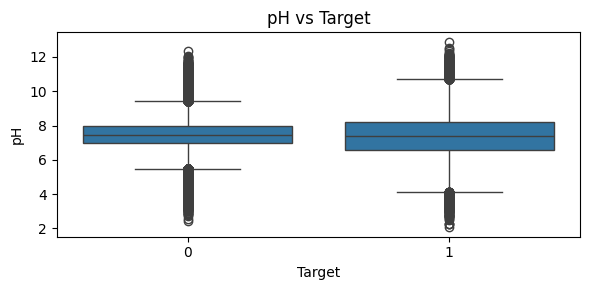

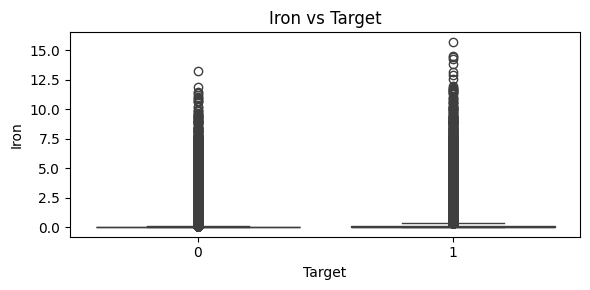

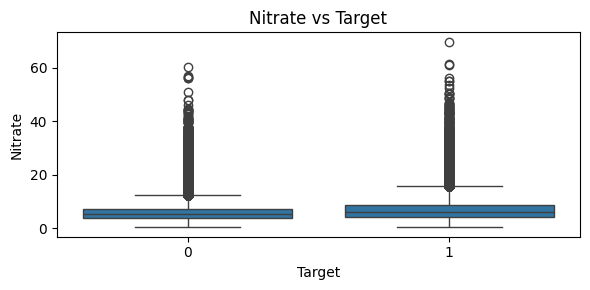

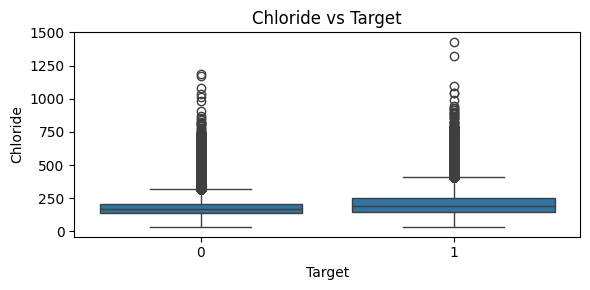

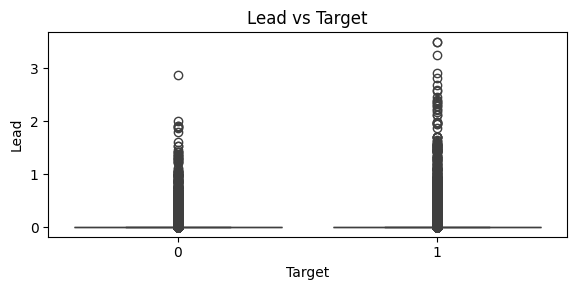

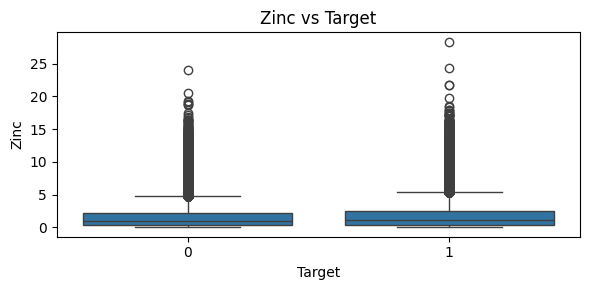

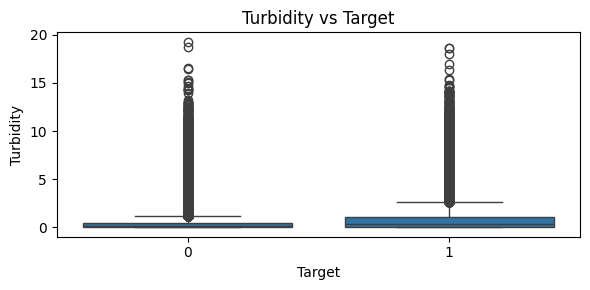

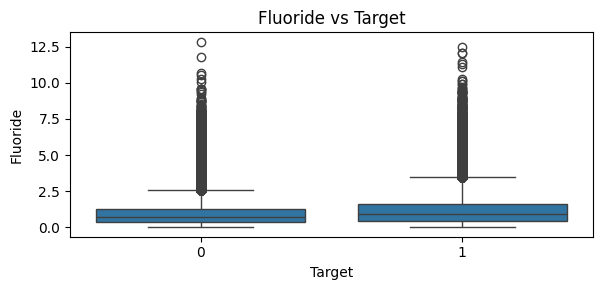

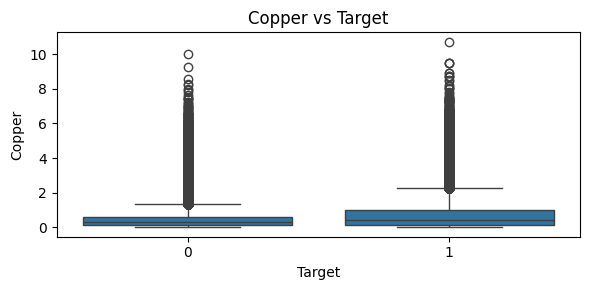

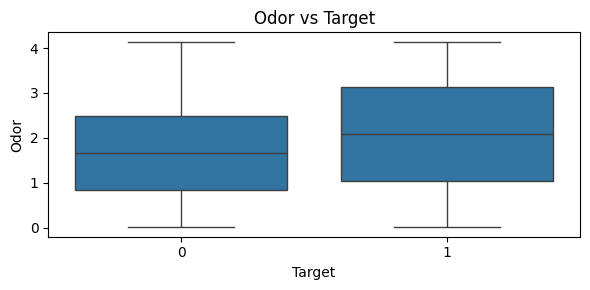

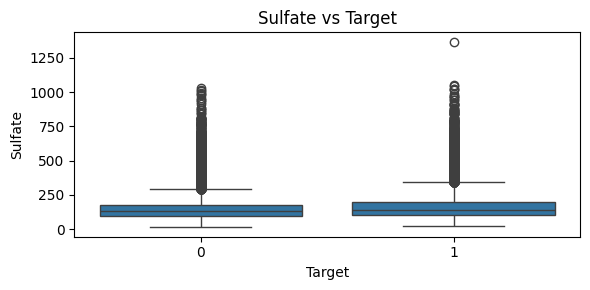

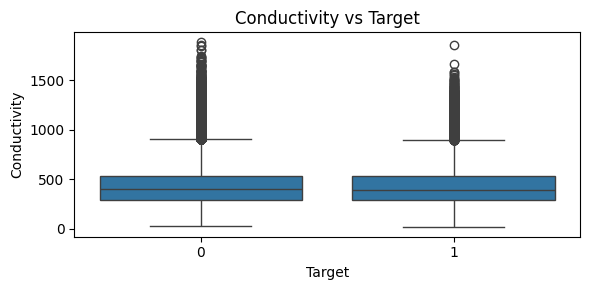

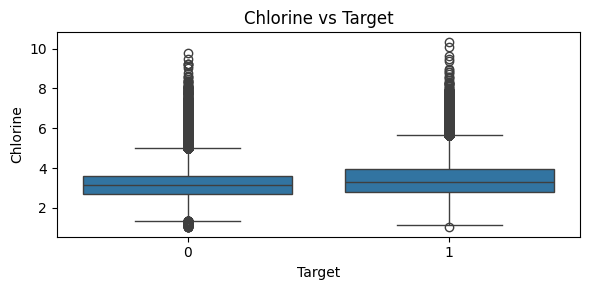

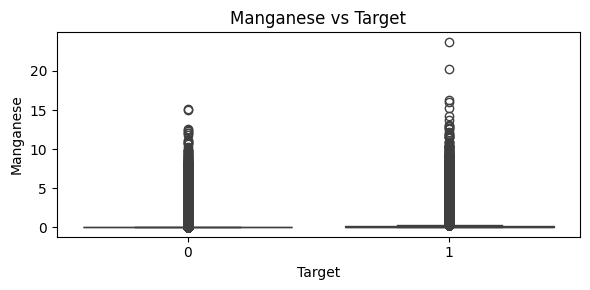

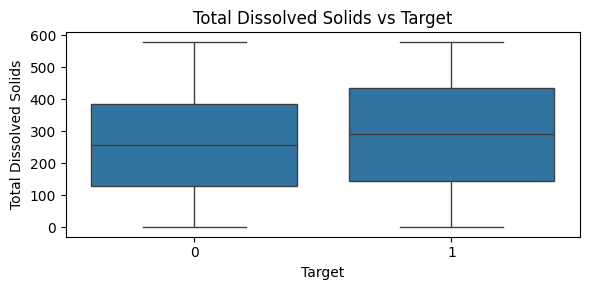

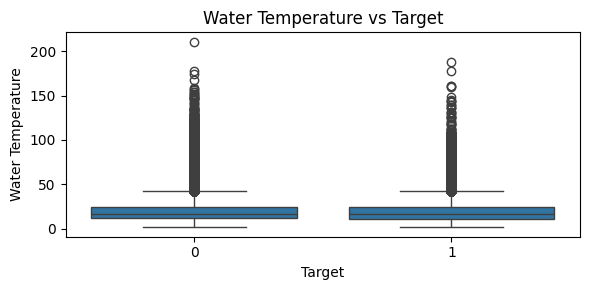

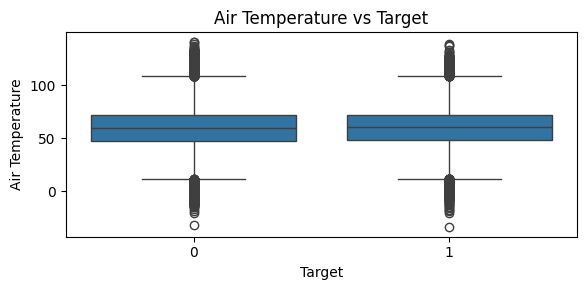

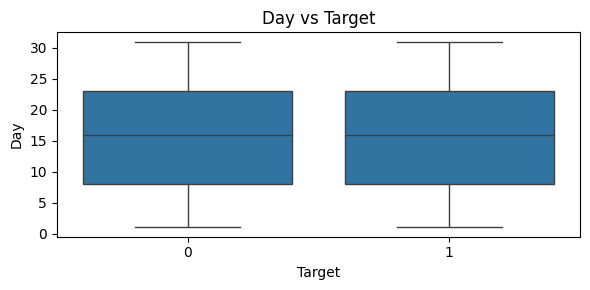

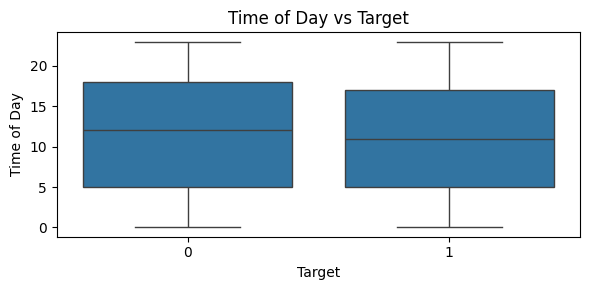

In [28]:
numerical_cols = water_quality_df.select_dtypes(include=['float64', 'int64']).drop(columns=['Target']).columns

for col in numerical_cols:
    plt.figure(figsize=(6, 3))
    sns.boxplot(data=water_quality_df, x='Target', y=col)
    plt.title(f'{col} vs Target')
    plt.tight_layout()
    plt.show()


**IQR BASED OUTLIER DETECTION:**

In [29]:
#  Get numerical columns excluding the target
numerical_cols = water_quality_df.select_dtypes(include=['float64', 'int64']).drop(columns=['Target']).columns

#  Detect and count outliers using IQR
outlier_summary = {}

for col in numerical_cols:
    Q1 = water_quality_df[col].quantile(0.25)
    Q3 = water_quality_df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Identify outliers
    outliers = water_quality_df[(water_quality_df[col] < lower_bound) | (water_quality_df[col] > upper_bound)]
    outlier_count = outliers.shape[0]
    outlier_summary[col] = outlier_count

#  Display sorted outlier counts
import pandas as pd

outlier_df = pd.DataFrame(list(outlier_summary.items()), columns=['Feature', 'Outlier_Count'])
outlier_df = outlier_df.sort_values(by='Outlier_Count', ascending=False)
print(outlier_df)


                   Feature  Outlier_Count
4                     Lead         172808
13               Manganese         112275
1                     Iron         112268
6                Turbidity          49169
8                   Copper          34311
15       Water Temperature          29507
7                 Fluoride          22093
2                  Nitrate          20810
3                 Chloride          20605
5                     Zinc          19731
0                       pH          18077
10                 Sulfate          16029
11            Conductivity          13319
12                Chlorine          11073
16         Air Temperature           4939
9                     Odor              0
14  Total Dissolved Solids              0
17                     Day              0
18             Time of Day              0


We have a lot of outliers, which we will handle further in data preprocessing step.

#**5. Introducing Imbalance**

In [30]:
import pandas as pd
from sklearn.utils import resample

# Separate the two classes
majority_class = water_quality_df[water_quality_df["Target"] == 0]  # Class 0 (Larger class)
minority_class = water_quality_df[water_quality_df["Target"] == 1]  # Class 1 (Smaller class)

# Function to generate imbalanced dataset
def generate_imbalanced_data(minority_ratio, majority_ratio):
    """
    Generates an imbalanced dataset with a specific class ratio.

    Parameters:
    - minority_ratio: The desired proportion of the minority class (e.g., 0.3 for 70/30).
    - majority_ratio: The desired proportion of the majority class (e.g., 0.7 for 70/30).

    Returns:
    - imbalanced_data: A pandas DataFrame containing the imbalanced dataset.
    """

    # Compute total dataset size based on the available minority samples
    total_samples = int(len(minority_class) / minority_ratio)

    # Calculate required class sizes
    maj_size = int(total_samples * majority_ratio)  # Required majority class size
    min_size = int(total_samples * minority_ratio)  # Required minority class size

    # Ensure we do not exceed available data
    maj_size = min(maj_size, len(majority_class))
    min_size = min(min_size, len(minority_class))

    # Downsample the majority and minority classes accordingly
    downsampled_majority = resample(majority_class, replace=False, n_samples=maj_size, random_state=42)
    downsampled_minority = resample(minority_class, replace=False, n_samples=min_size, random_state=42)

    # Combine both classes
    imbalanced_data = pd.concat([downsampled_majority, downsampled_minority])

    # Shuffle the dataset to mix the classes
    imbalanced_data = imbalanced_data.sample(frac=1, random_state=42).reset_index(drop=True)

    return imbalanced_data

# 1. **Slightly Imbalanced (70/30)**
slightly_imbalanced = generate_imbalanced_data(0.3, 0.7)

# 2. **Moderately Imbalanced (80/20)**
moderately_imbalanced = generate_imbalanced_data(0.2, 0.8)

# 3. **Severely Imbalanced (95/5)**
severely_imbalanced = generate_imbalanced_data(0.05, 0.95)

# Check the class distribution in the imbalanced datasets
print("Slightly Imbalanced Class Distribution:")
print(slightly_imbalanced['Target'].value_counts())

print("\nModerately Imbalanced Class Distribution:")
print(moderately_imbalanced['Target'].value_counts())

print("\nSeverely Imbalanced Class Distribution:")
print(severely_imbalanced['Target'].value_counts())

# Save the datasets
slightly_imbalanced.to_csv("water_quality_slightly_imbalanced.csv", index=False)
moderately_imbalanced.to_csv("water_quality_moderately_imbalanced.csv", index=False)
severely_imbalanced.to_csv("water_quality_severely_imbalanced.csv", index=False)


Slightly Imbalanced Class Distribution:
Target
0    376327
1    161283
Name: count, dtype: int64

Moderately Imbalanced Class Distribution:
Target
0    539773
1    161283
Name: count, dtype: int64

Severely Imbalanced Class Distribution:
Target
0    539773
1    161283
Name: count, dtype: int64


In [31]:
slightly_imbalanced.shape

(537610, 23)

#**6. Baseline Models(Without Preprocessing- PreEncoding)**

In [33]:
# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import Counter

# Select only numerical features (exclude 'Target')
X = slightly_imbalanced.select_dtypes(include=['float64', 'int64']).drop(columns=['Target'])
y = slightly_imbalanced['Target']

#  Print class distribution to confirm imbalance
print("🔍 Class Distribution:")
print(Counter(y))

# Train-Test Split (Stratified to preserve class imbalance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.99, random_state=42, stratify=y
)

#  Define Models
models = {
    'Dummy Classifier': DummyClassifier(strategy='most_frequent'),  # Baseline model
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),

}

#  Train & Evaluate
results = {}

for name, model in models.items():
    print("="*50)
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n🔹 Accuracy for {name}: {accuracy:.2f}")
    print(f"🔹 F1 Score for {name}: {f1:.2f}")
    print(f"\n🔹 Classification Report for {name}:\n{classification_report(y_test, y_pred, zero_division=1)}")

    results[name] = {'Accuracy': accuracy, 'F1-Score': f1}

#  Summary
print("\n\n📊 Model Performance Comparison (Slightly Imbalanced Dataset):")
print("="*50)
for model_name, metrics in results.items():
    print(f"✅ {model_name}: Accuracy = {metrics['Accuracy']:.2f}, F1-Score = {metrics['F1-Score']:.2f}")


🔍 Class Distribution:
Counter({0: 376327, 1: 161283})
Training Dummy Classifier...

🔹 Accuracy for Dummy Classifier: 0.70
🔹 F1 Score for Dummy Classifier: 0.58

🔹 Classification Report for Dummy Classifier:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82    372564
           1       1.00      0.00      0.00    159670

    accuracy                           0.70    532234
   macro avg       0.85      0.50      0.41    532234
weighted avg       0.79      0.70      0.58    532234

Training Logistic Regression...


/usr/local/lib/python3.11/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



🔹 Accuracy for Logistic Regression: 0.77
🔹 F1 Score for Logistic Regression: 0.75

🔹 Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.78      0.93      0.85    372564
           1       0.71      0.39      0.51    159670

    accuracy                           0.77    532234
   macro avg       0.75      0.66      0.68    532234
weighted avg       0.76      0.77      0.75    532234

Training Random Forest...

🔹 Accuracy for Random Forest: 0.88
🔹 F1 Score for Random Forest: 0.88

🔹 Classification Report for Random Forest:
              precision    recall  f1-score   support

           0       0.98      0.84      0.91    372564
           1       0.72      0.96      0.82    159670

    accuracy                           0.88    532234
   macro avg       0.85      0.90      0.87    532234
weighted avg       0.90      0.88      0.88    532234

Training Decision Tree...

🔹 Accuracy for Decision Tree: 0.82
🔹 F1 Score

In [ ]:
!pip install catboost

#**7. Data Preprocessing**

**1. Capping Outliers. We saw that there were many outliers , so we are capping them .**

In [34]:
# Step 1: Select only numeric columns (excluding 'Target')
feature_columns = [col for col in slightly_imbalanced.columns if slightly_imbalanced[col].dtype in ['float64', 'int64'] and col != "Target"]

# Step 2: Compute Q1, Q3, and IQR
Q1 = slightly_imbalanced[feature_columns].quantile(0.25)
Q3 = slightly_imbalanced[feature_columns].quantile(0.75)
IQR = Q3 - Q1

# Step 3: Define lower and upper bounds for outlier detection
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# Step 4: Identify and count outliers
outliers = ((slightly_imbalanced[feature_columns] < lower_bound) | (slightly_imbalanced[feature_columns] > upper_bound))
outliers_count = outliers.sum()
print("Outliers detected in each column:\n", outliers_count)

# Step 5: Capping values within the valid range
capped_df = slightly_imbalanced.copy()

# Clip each feature column
for col in feature_columns:
    capped_df[col] = capped_df[col].clip(lower=lower_bound[col], upper=upper_bound[col])

# Step 6: Display results
print("\n✅ Outlier capping applied successfully.")
print("🔍 Dataset preview after capping:")
print(capped_df.head())

# Optional: Confirm dataset size consistency
print(f"\n📊 Dataset size before: {slightly_imbalanced.shape[0]} rows")
print(f"📊 Dataset size after : {capped_df.shape[0]} rows")


Outliers detected in each column:
 pH                         14253
Iron                       86200
Nitrate                    17713
Chloride                   17219
Lead                      132559
Zinc                       16267
Turbidity                  41594
Fluoride                   18725
Copper                     28768
Odor                           0
Sulfate                    13686
Conductivity               10295
Chlorine                    9222
Manganese                  86160
Total Dissolved Solids         0
Water Temperature          22698
Air Temperature             3806
Day                            0
Time of Day                    0
dtype: int64

✅ Outlier capping applied successfully.
🔍 Dataset preview after capping:
         pH      Iron    Nitrate    Chloride           Lead      Zinc  \
0  5.802453  0.000605   4.049367  119.272044   2.880000e-55  3.565396   
1  7.179803  0.007063   4.586921  134.799853  1.240000e-175  0.769435   
2  7.194964  0.000087  11.591095

**2. For correlation: There are no highly correlated feature pairs in the dataset. So lets keep all the features. We also saw above that VIF scires are close or almost 1.**

**3. Encoding Catagorical variables.**

In [35]:
# Step 1: Identify categorical columns
categorical_cols = capped_df.select_dtypes(include=['object']).columns
print("Categorical Columns to Encode:", list(categorical_cols))

# Step 2: Apply One-Hot Encoding
df_encoded = pd.get_dummies(capped_df, columns=categorical_cols, drop_first=True)

print("✅ One-Hot Encoding applied.")
print("🔍 Encoded DataFrame shape:", df_encoded.shape)
print("🔍 Encoded Columns Preview:")
print(df_encoded.columns)


Categorical Columns to Encode: ['Color', 'Source', 'Month']
✅ One-Hot Encoding applied.
🔍 Encoded DataFrame shape: (537610, 41)
🔍 Encoded Columns Preview:
Index(['pH', 'Iron', 'Nitrate', 'Chloride', 'Lead', 'Zinc', 'Turbidity',
       'Fluoride', 'Copper', 'Odor', 'Sulfate', 'Conductivity', 'Chlorine',
       'Manganese', 'Total Dissolved Solids', 'Water Temperature',
       'Air Temperature', 'Day', 'Time of Day', 'Target', 'Color_faint yellow',
       'Color_light yellow', 'Color_yellow', 'Source_ground', 'Source_lake',
       'Source_reservoir', 'Source_river', 'Source_spring', 'Source_stream',
       'Source_well', 'Month_august', 'Month_december', 'Month_february',
       'Month_january', 'Month_july', 'Month_june', 'Month_march', 'Month_may',
       'Month_november', 'Month_october', 'Month_september'],
      dtype='object')


**4. Feature Scaling**

In [36]:
from sklearn.preprocessing import StandardScaler

# Step 1: Separate features and target
X = df_encoded.drop(columns=['Target'])
y = df_encoded['Target']

# Step 2: Scale only numerical columns (exclude one-hot columns)
numerical_cols = [col for col in X.columns if df_encoded[col].dtype in ['float64', 'int64']]

# Step 3: Initialize and apply scaler
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(" Feature scaling applied to numerical columns.")
print(" Scaled DataFrame shape:", X_scaled.shape)


 Feature scaling applied to numerical columns.
 Scaled DataFrame shape: (537610, 40)


In [ ]:
X_scaled[numerical_cols].describe().round(2)


#**8. Baseline Models(With Preprocessing- Encoding)**

In [37]:
# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.dummy import DummyClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, f1_score
from collections import Counter

# Use cleaned + scaled features and target
# X_scaled and y should already be defined from earlier steps
print("🔍 Class Distribution:")
print(Counter(y))

# Train-Test Split (Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.99, random_state=42, stratify=y
)

# Define Models
models = {
    'Dummy Classifier': DummyClassifier(strategy='most_frequent'),  # Baseline
    'Logistic Regression': LogisticRegression(max_iter=200),
    'Random Forest': RandomForestClassifier(),
    'Decision Tree': DecisionTreeClassifier(),
}

# Train & Evaluate
results = {}

for name, model in models.items():
    print("="*50)
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')

    print(f"\n🔹 Accuracy for {name}: {accuracy:.2f}")
    print(f"🔹 F1 Score for {name}: {f1:.2f}")
    print(f"\n🔹 Classification Report for {name}:\n{classification_report(y_test, y_pred, zero_division=1)}")

    results[name] = {'Accuracy': accuracy, 'F1-Score': f1}

# Summary
print("\n\n📊 Model Performance Comparison (Cleaned + Scaled Dataset):")
print("="*50)
for model_name, metrics in results.items():
    print(f"✅ {model_name}: Accuracy = {metrics['Accuracy']:.2f}, F1-Score = {metrics['F1-Score']:.2f}")


🔍 Class Distribution:
Counter({0: 376327, 1: 161283})
Training Dummy Classifier...

🔹 Accuracy for Dummy Classifier: 0.70
🔹 F1 Score for Dummy Classifier: 0.58

🔹 Classification Report for Dummy Classifier:
              precision    recall  f1-score   support

           0       0.70      1.00      0.82    372564
           1       1.00      0.00      0.00    159670

    accuracy                           0.70    532234
   macro avg       0.85      0.50      0.41    532234
weighted avg       0.79      0.70      0.58    532234

Training Logistic Regression...

🔹 Accuracy for Logistic Regression: 0.79
🔹 F1 Score for Logistic Regression: 0.78

🔹 Classification Report for Logistic Regression:
              precision    recall  f1-score   support

           0       0.82      0.90      0.86    372564
           1       0.70      0.53      0.60    159670

    accuracy                           0.79    532234
   macro avg       0.76      0.72      0.73    532234
weighted avg       0.78      

#**9. Applying Imbalance Techniques for Models(With Preprocessing- Encoding)**

In [38]:
# Imports
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
#from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier
from imblearn.over_sampling import SMOTE, BorderlineSMOTE, RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler, NearMiss, ClusterCentroids, TomekLinks
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Train-Test Split (Preprocessed Data)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.99, random_state=42, stratify=y
)

#  Models
models = {
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000, class_weight="balanced"),
    "Decision Tree": DecisionTreeClassifier(random_state=42, class_weight="balanced"),
    "Random Forest": RandomForestClassifier(random_state=42, class_weight="balanced"),
    #"SVM": SVC(random_state=42, class_weight="balanced"),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "Gaussian Naive Bayes": GaussianNB(),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric="logloss", random_state=42),
    "LightGBM": LGBMClassifier(random_state=42, verbose=-1),
    "Extra Trees": ExtraTreesClassifier(random_state=42),
    "Balanced Random Forest": BalancedRandomForestClassifier(random_state=42),
    "Easy Ensemble": EasyEnsembleClassifier(random_state=42),
}

#  Resampling Methods
imbalance_methods = {
    "SMOTE": SMOTE(random_state=42),
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "Cluster Centroids": ClusterCentroids(random_state=42),
    "NearMiss": NearMiss(version=1)
}

#  Evaluation
results_processed = {}

for method_name, sampler in imbalance_methods.items():
    print(f"\n🔁 Resampling Method: {method_name}")
    X_resampled, y_resampled = sampler.fit_resample(X_train, y_train)

    for model_name, model in models.items():
        print(f"\nModel: {model_name}")
        model.fit(X_resampled, y_resampled)
        y_pred = model.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = classification_report(y_test, y_pred, output_dict=True, zero_division=0)['weighted avg']['f1-score']
        precision = classification_report(y_test, y_pred, output_dict=True, zero_division=0)['weighted avg']['precision']
        recall = classification_report(y_test, y_pred, output_dict=True, zero_division=0)['weighted avg']['recall']
        confusion = confusion_matrix(y_test, y_pred)

        results_processed[(method_name, model_name)] = {
            "Accuracy": accuracy,
            "F1-Score": f1,
            "Precision": precision,
            "Recall": recall,
            "Classification Report": classification_report(y_test, y_pred, zero_division=0),
            "Confusion Matrix": confusion
        }

        print(f"✅ Accuracy: {accuracy:.4f}")
        print(f"✅ F1-Score: {f1:.4f}")
        print(f"✅ Precision: {precision:.4f}")
        print(f"✅ Recall: {recall:.4f}")
        print("📌 Confusion Matrix:")
        print(confusion)



🔁 Resampling Method: SMOTE

Model: Logistic Regression
✅ Accuracy: 0.7881
✅ F1-Score: 0.7858
✅ Precision: 0.7843
✅ Recall: 0.7881
📌 Confusion Matrix:
[[321631  50933]
 [ 61867  97803]]

Model: Decision Tree
✅ Accuracy: 0.7991
✅ F1-Score: 0.8005
✅ Precision: 0.8024
✅ Recall: 0.7991
📌 Confusion Matrix:
[[314939  57625]
 [ 49285 110385]]

Model: Random Forest
✅ Accuracy: 0.8633
✅ F1-Score: 0.8679
✅ Precision: 0.8914
✅ Recall: 0.8633
📌 Confusion Matrix:
[[308543  64021]
 [  8717 150953]]

Model: KNN
✅ Accuracy: 0.7704
✅ F1-Score: 0.7594
✅ Precision: 0.7592
✅ Recall: 0.7704
📌 Confusion Matrix:
[[332091  40473]
 [ 81739  77931]]

Model: Gaussian Naive Bayes
✅ Accuracy: 0.8203
✅ F1-Score: 0.8222
✅ Precision: 0.8250
✅ Recall: 0.8203
📌 Confusion Matrix:
[[318426  54138]
 [ 41513 118157]]

Model: Gradient Boosting
✅ Accuracy: 0.8432
✅ F1-Score: 0.8453
✅ Precision: 0.8494
✅ Recall: 0.8432
📌 Confusion Matrix:
[[322233  50331]
 [ 33127 126543]]

Model: XGBoost


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [14:59:34] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Accuracy: 0.8395
✅ F1-Score: 0.8413
✅ Precision: 0.8445
✅ Recall: 0.8395
📌 Confusion Matrix:
[[322734  49830]
 [ 35604 124066]]

Model: LightGBM
✅ Accuracy: 0.8521
✅ F1-Score: 0.8558
✅ Precision: 0.8676
✅ Recall: 0.8521
📌 Confusion Matrix:
[[315253  57311]
 [ 21418 138252]]

Model: Extra Trees
✅ Accuracy: 0.8284
✅ F1-Score: 0.8306
✅ Precision: 0.8343
✅ Recall: 0.8284
📌 Confusion Matrix:
[[318971  53593]
 [ 37758 121912]]

Model: Balanced Random Forest
✅ Accuracy: 0.8616
✅ F1-Score: 0.8664
✅ Precision: 0.8907
✅ Recall: 0.8616
📌 Confusion Matrix:
[[307505  65059]
 [  8579 151091]]

Model: Easy Ensemble
✅ Accuracy: 0.8253
✅ F1-Score: 0.8253
✅ Precision: 0.8253
✅ Recall: 0.8253
📌 Confusion Matrix:
[[326166  46398]
 [ 46579 113091]]

🔁 Resampling Method: Random Oversampling

Model: Logistic Regression
✅ Accuracy: 0.7913
✅ F1-Score: 0.7959
✅ Precision: 0.8056
✅ Recall: 0.7913
📌 Confusion Matrix:
[[302056  70508]
 [ 40563 119107]]

Model: Decision Tree
✅ Accuracy: 0.8003
✅ F1-Score: 0.7986


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:02:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Accuracy: 0.8446
✅ F1-Score: 0.8466
✅ Precision: 0.8502
✅ Recall: 0.8446
📌 Confusion Matrix:
[[323212  49352]
 [ 33379 126291]]

Model: LightGBM
✅ Accuracy: 0.8612
✅ F1-Score: 0.8651
✅ Precision: 0.8807
✅ Recall: 0.8612
📌 Confusion Matrix:
[[314083  58481]
 [ 15417 144253]]

Model: Extra Trees
✅ Accuracy: 0.8195
✅ F1-Score: 0.8183
✅ Precision: 0.8175
✅ Recall: 0.8195
📌 Confusion Matrix:
[[327965  44599]
 [ 51466 108204]]

Model: Balanced Random Forest
✅ Accuracy: 0.8643
✅ F1-Score: 0.8687
✅ Precision: 0.8901
✅ Recall: 0.8643
📌 Confusion Matrix:
[[310256  62308]
 [  9935 149735]]

Model: Easy Ensemble
✅ Accuracy: 0.8394
✅ F1-Score: 0.8404
✅ Precision: 0.8415
✅ Recall: 0.8394
📌 Confusion Matrix:
[[326543  46021]
 [ 39430 120240]]

🔁 Resampling Method: Borderline-SMOTE

Model: Logistic Regression
✅ Accuracy: 0.7887
✅ F1-Score: 0.7867
✅ Precision: 0.7853
✅ Recall: 0.7887
📌 Confusion Matrix:
[[321448  51116]
 [ 61323  98347]]

Model: Decision Tree
✅ Accuracy: 0.8026
✅ F1-Score: 0.8040
✅ P

...

✅ Accuracy: 0.8434
✅ F1-Score: 0.8453
✅ Precision: 0.8484
✅ Recall: 0.8434
📌 Confusion Matrix:
[[323737  48827]
 [ 34506 125164]]

Model: LightGBM
✅ Accuracy: 0.8553
✅ F1-Score: 0.8585
✅ Precision: 0.8674
✅ Recall: 0.8553
📌 Confusion Matrix:
[[319056  53508]
 [ 23498 136172]]

Model: Extra Trees
✅ Accuracy: 0.8287
✅ F1-Score: 0.8295
✅ Precision: 0.8306
✅ Recall: 0.8287
📌 Confusion Matrix:
[[324025  48539]
 [ 42651 117019]]

Model: Balanced Random Forest
✅ Accuracy: 0.8612
✅ F1-Score: 0.8663
✅ Precision: 0.8961
✅ Recall: 0.8612
📌 Confusion Matrix:
[[303782  68782]
 [  5074 154596]]

Model: Easy Ensemble
✅ Accuracy: 0.8448
✅ F1-Score: 0.8465
✅ Precision: 0.8492
✅ Recall: 0.8448
📌 Confusion Matrix:
[[324829  47735]
 [ 34851 124819]]

🔁 Resampling Method: Cluster Centroids

Model: Logistic Regression
✅ Accuracy: 0.6461
✅ F1-Score: 0.6598
✅ Precision: 0.7529
✅ Recall: 0.6461
📌 Confusion Matrix:
[[212585 159979]
 [ 28354 131316]]

Model: Decision Tree
✅ Accuracy: 0.7741
✅ F1-Score: 0.7787
✅ 

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:12:24] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Accuracy: 0.8184
✅ F1-Score: 0.8234
✅ Precision: 0.8376
✅ Recall: 0.8184
📌 Confusion Matrix:
[[304324  68240]
 [ 28406 131264]]

Model: LightGBM
✅ Accuracy: 0.8442
✅ F1-Score: 0.8488
✅ Precision: 0.8655
✅ Recall: 0.8442
📌 Confusion Matrix:
[[308766  63798]
 [ 19115 140555]]

Model: Extra Trees
✅ Accuracy: 0.8106
✅ F1-Score: 0.8174
✅ Precision: 0.8462
✅ Recall: 0.8106
📌 Confusion Matrix:
[[291088  81476]
 [ 19355 140315]]

Model: Balanced Random Forest
✅ Accuracy: 0.8584
✅ F1-Score: 0.8634
✅ Precision: 0.8896
✅ Recall: 0.8584
📌 Confusion Matrix:
[[305349  67215]
 [  8141 151529]]

Model: Easy Ensemble
✅ Accuracy: 0.8257
✅ F1-Score: 0.8286
✅ Precision: 0.8341
✅ Recall: 0.8257
📌 Confusion Matrix:
[[315705  56859]
 [ 35886 123784]]

🔁 Resampling Method: NearMiss

Model: Logistic Regression
✅ Accuracy: 0.7478
✅ F1-Score: 0.7578
✅ Precision: 0.7979
✅ Recall: 0.7478
📌 Confusion Matrix:
[[267223 105341]
 [ 28871 130799]]

Model: Decision Tree
✅ Accuracy: 0.8229
✅ F1-Score: 0.8291
✅ Precision

/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [15:14:36] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✅ Accuracy: 0.8580
✅ F1-Score: 0.8628
✅ Precision: 0.8863
✅ Recall: 0.8580
📌 Confusion Matrix:
[[307102  65462]
 [ 10137 149533]]

Model: LightGBM
✅ Accuracy: 0.8610
✅ F1-Score: 0.8660
✅ Precision: 0.8931
✅ Recall: 0.8610
📌 Confusion Matrix:
[[305469  67095]
 [  6859 152811]]

Model: Extra Trees
✅ Accuracy: 0.8251
✅ F1-Score: 0.8316
✅ Precision: 0.8644
✅ Recall: 0.8251
📌 Confusion Matrix:
[[292337  80227]
 [ 12884 146786]]

Model: Balanced Random Forest
✅ Accuracy: 0.8592
✅ F1-Score: 0.8644
✅ Precision: 0.8975
✅ Recall: 0.8592
📌 Confusion Matrix:
[[301268  71296]
 [  3665 156005]]

Model: Easy Ensemble
✅ Accuracy: 0.8560
✅ F1-Score: 0.8592
✅ Precision: 0.8680
✅ Recall: 0.8560
📌 Confusion Matrix:
[[319277  53287]
 [ 23343 136327]]


**Metrices Table**

In [45]:
import pandas as pd
from IPython.display import display

# Optional: show all rows and columns in Jupyter
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Prepare data from results_processed dictionary
results_list = []

for key, metrics in results_processed.items():
    if isinstance(key, tuple) and len(key) == 2:
        resampling_method, model_name = key
    else:
        continue

    row = {
        "Resampling Method": resampling_method,
        "Model": model_name,
        "Accuracy": round(metrics.get("Accuracy", 0), 6),
        "F1-Score": round(metrics.get("F1-Score", 0), 6),
        "Precision": round(metrics.get("Precision", 0), 6),
        "Recall": round(metrics.get("Recall", 0), 6)
    }
    results_list.append(row)

# Convert to DataFrame
results_df = pd.DataFrame(results_list)

# Sort by Resampling Method then Model name
results_df = results_df.sort_values(by=["Resampling Method", "Model"]).reset_index(drop=True)

# Display the DataFrame
display(results_df)


,Resampling Method,Model,Accuracy,F1-Score,Precision,Recall
0,Borderline-SMOTE,Balanced Random Forest,0.862545,0.867211,0.891141,0.862545
1,Borderline-SMOTE,Decision Tree,0.802600,0.804005,0.805836,0.802600
2,Borderline-SMOTE,Easy Ensemble,0.829267,0.829718,0.830228,0.829267
3,Borderline-SMOTE,Extra Trees,0.827317,0.829611,0.833600,0.827317
4,Borderline-SMOTE,Gaussian Naive Bayes,0.820166,0.822091,0.825061,0.820166
5,Borderline-SMOTE,Gradient Boosting,0.843405,0.845742,0.850332,0.843405
6,Borderline-SMOTE,KNN,0.772275,0.761744,0.761450,0.772275
7,Borderline-SMOTE,LightGBM,0.853005,0.856704,0.868385,0.853005
8,Borderline-SMOTE,Logistic Regression,0.788741,0.786681,0.785255,0.788741
9,Borderline-SMOTE,Random Forest,0.860723,0.865516,0.890453,0.860723


**Bar Plots of F1-Score by Resampling Method & Model (Post-Preprocessing)**

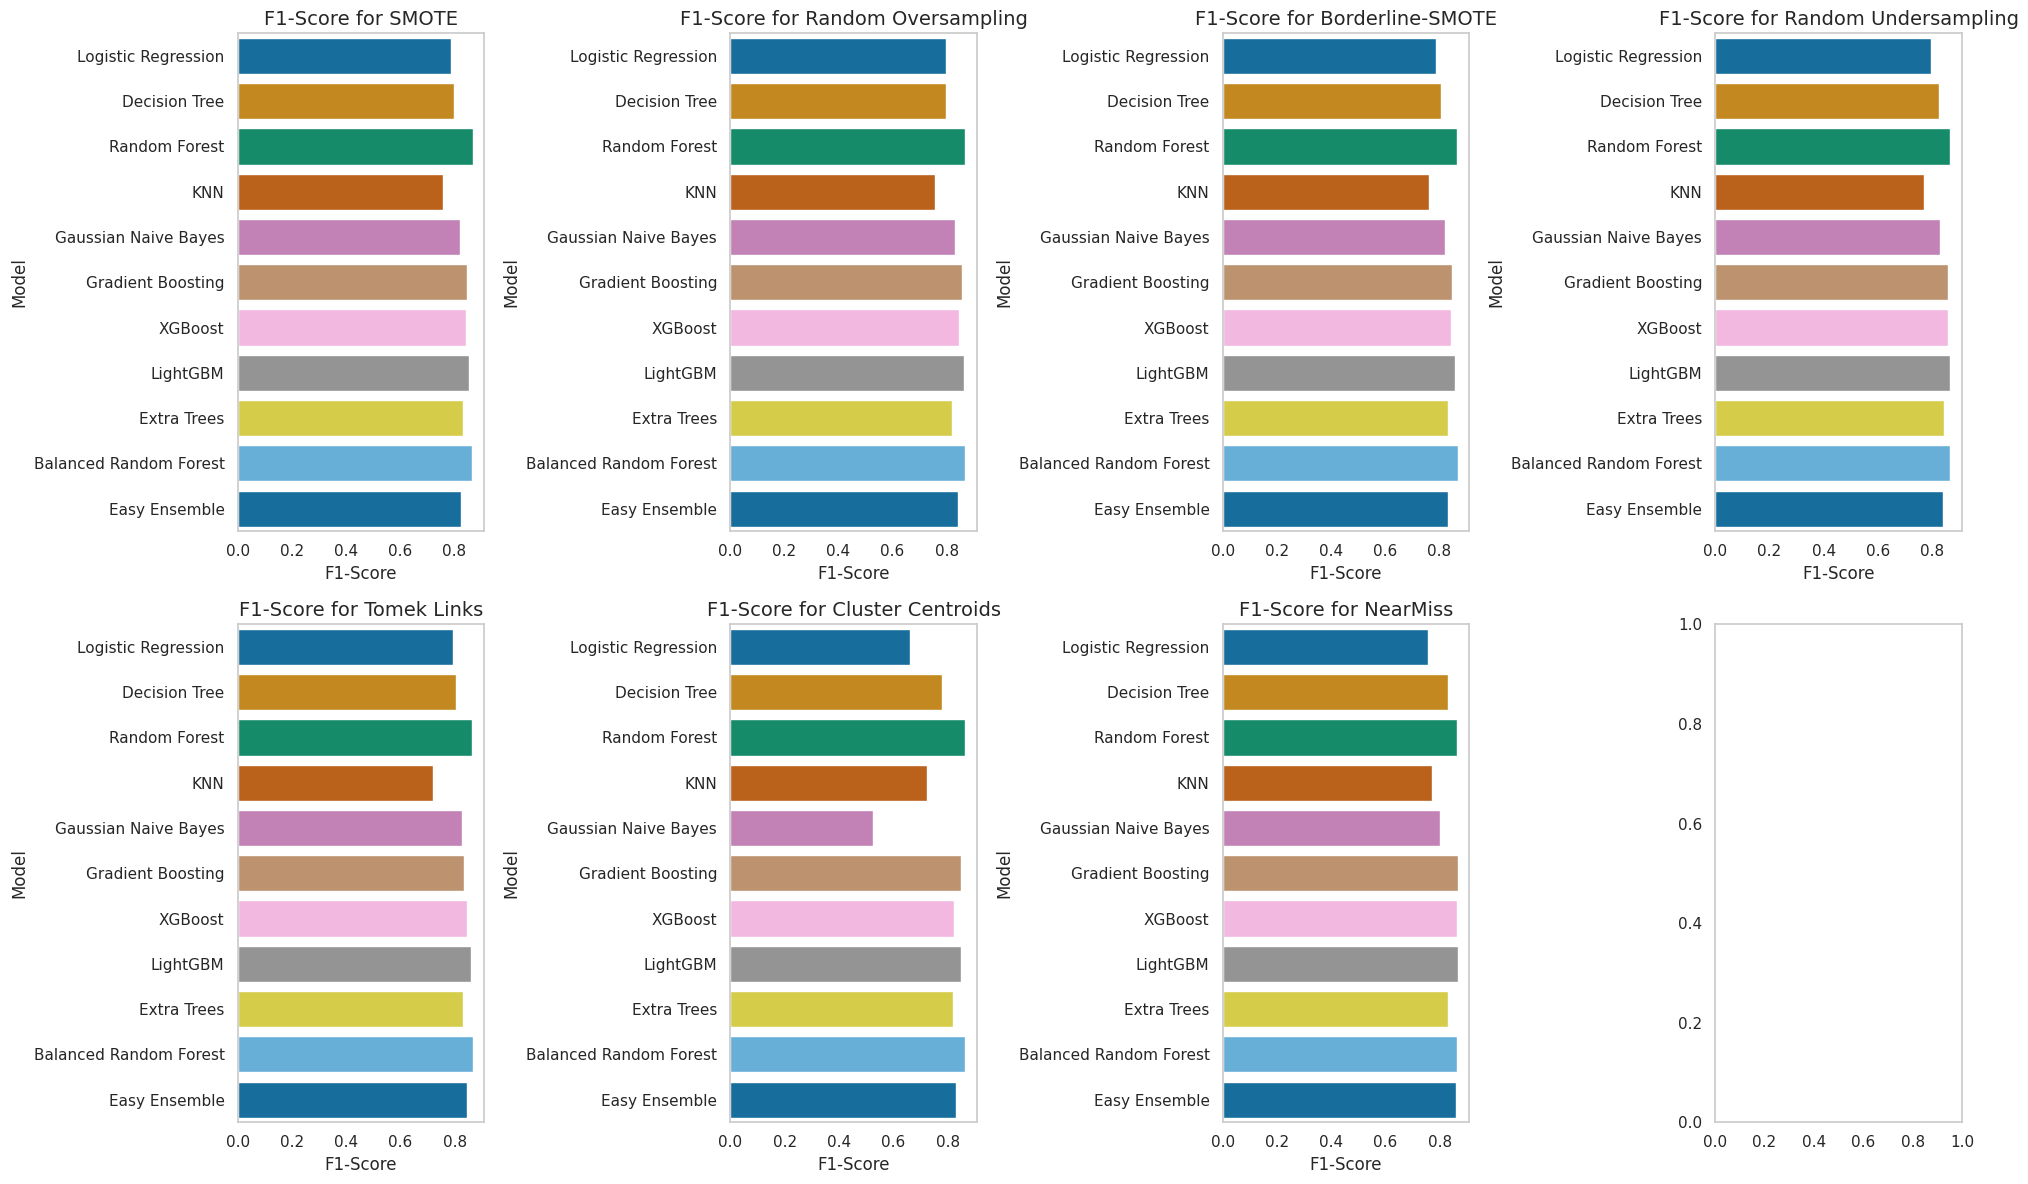

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Create the plot with subplots
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 12))  # Adjust rows/columns as needed
axes = axes.flatten()

# List of resampling methods (excluding "Original Data")
resampling_methods = results_df[results_df['Resampling Method'] != "Original Data"]['Resampling Method'].unique()

# Plot each resampling method
for ax, method in zip(axes, resampling_methods):
    # Filter data for the specific resampling method
    method_data = results_df[results_df['Resampling Method'] == method]

    if method_data.empty:  # Check if method_data has any entries
        continue  # Skip empty method data

    # Create the barplot using color-blind-friendly palette
    sns.barplot(x='F1-Score', y='Model', data=method_data, ax=ax, palette="colorblind")

    # Set the title and labels
    ax.set_title(f"F1-Score for {method}", fontsize=14)
    ax.set_xlabel('F1-Score', fontsize=12)
    ax.set_ylabel('Model', fontsize=12)

# **Remove grid lines from all subplots**
for ax in axes:
    ax.grid(False)  # <-- This removes the grid lines

# Adjust layout to avoid overlap
plt.tight_layout()

# Show the final plot
plt.show()


**Best Model for each Sampling technique**

In [47]:
import pandas as pd

# Assuming your DataFrame is named `results_df`
# Replace this with your actual DataFrame if named differently
best_models = results_df.loc[results_df.groupby("Resampling Method")["F1-Score"].idxmax()].reset_index(drop=True)

# Sort for readability
best_models = best_models.sort_values(by="Resampling Method").reset_index(drop=True)

from IPython.display import display
display(best_models)


,Resampling Method,Model,Accuracy,F1-Score,Precision,Recall
0,Borderline-SMOTE,Balanced Random Forest,0.862545,0.867211,0.891141,0.862545
1,Cluster Centroids,Balanced Random Forest,0.858416,0.863371,0.889639,0.858416
2,NearMiss,Gradient Boosting,0.862014,0.866205,0.883982,0.862014
3,Random Oversampling,Balanced Random Forest,0.864265,0.868696,0.890126,0.864265
4,Random Undersampling,LightGBM,0.862175,0.866830,0.890424,0.862175
5,SMOTE,Random Forest,0.863335,0.867943,0.891425,0.863335
6,Tomek Links,Balanced Random Forest,0.861234,0.866287,0.896125,0.861234


**Cross-Validation Code (Only Best Models)**

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score
import numpy as np
import pandas as pd
from IPython.display import display

# Just the best models and their corresponding samplers
best_model_configs = [
    ("Borderline-SMOTE", BalancedRandomForestClassifier(random_state=42)),
    ("Cluster Centroids", BalancedRandomForestClassifier(random_state=42)),
    ("NearMiss", GradientBoostingClassifier(random_state=42)),
    ("Random Oversampling", BalancedRandomForestClassifier(random_state=42)),
    ("Random Undersampling", LGBMClassifier(random_state=42, verbose=-1)),
    ("SMOTE", RandomForestClassifier(random_state=42, class_weight="balanced")),
    ("Tomek Links", BalancedRandomForestClassifier(random_state=42)),
]

# Get the correct samplers from your original imbalance_methods dictionary
samplers = {
    "SMOTE": SMOTE(random_state=42),
    "Random Oversampling": RandomOverSampler(random_state=42),
    "Borderline-SMOTE": BorderlineSMOTE(random_state=42),
    "Random Undersampling": RandomUnderSampler(random_state=42),
    "Tomek Links": TomekLinks(),
    "Cluster Centroids": ClusterCentroids(random_state=42),
    "NearMiss": NearMiss(version=1),
}

# Cross-validation setup
kf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)  # use 3 for speed

results = []

for method, model in best_model_configs:
    sampler = samplers[method]
    f1s, accs, precs, recalls = [], [], [], []

    for train_idx, test_idx in kf.split(X_scaled, y):
        X_train, X_test = X_scaled.iloc[train_idx], X_scaled.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        X_res, y_res = sampler.fit_resample(X_train, y_train)
        model.fit(X_res, y_res)
        y_pred = model.predict(X_test)

        f1s.append(f1_score(y_test, y_pred, average='weighted', zero_division=0))
        accs.append(accuracy_score(y_test, y_pred))
        precs.append(precision_score(y_test, y_pred, average='weighted', zero_division=0))
        recalls.append(recall_score(y_test, y_pred, average='weighted', zero_division=0))

    results.append({
        "Resampling Method": method,
        "Model": type(model).__name__,
        "CV Avg F1-Score": np.mean(f1s),
        "CV Avg Accuracy": np.mean(accs),
        "CV Avg Precision": np.mean(precs),
        "CV Avg Recall": np.mean(recalls),
    })

cv_df = pd.DataFrame(results).sort_values(by="CV Avg F1-Score", ascending=False).reset_index(drop=True)
display(cv_df)
